---
# DAY 3 — Feature Selection & Classification
---

## Step 10 — Reload Feature Stack

Start a fresh notebook or restart the kernel. Reload everything from Blob Storage.

🎯 Reload `feat_arr` and `feat_names` from Blob Storage and `feature_names.json`.

In [ ]:
# Paste your helper functions (get_cc, read_blob, write_blob) here
# YOUR CODE HERE
import numpy as np
import rasterio
from rasterio.io import MemoryFile
from azure.storage.blob import BlobServiceClient
import json 

import io

import config

NO_DATA = -9999.0

#Connection string format: `DefaultEndpointsProtocol=https;AccountName=...;AccountKey=...;EndpointSuffix=core.windows.net`
acc_name = config.ACCOUNT_NAME
acc_key = config.ACCOUNT_KEY

conn_str = f"DefaultEndpointsProtocol=https;AccountName={acc_name};AccountKey={acc_key};EndpointSuffix=core.windows.net"


def get_cc():
    """
    Return an Azure Blob container client using credentials from config.
    """
    # Build connection string and return container client
    # YOUR CODE HERE
    service_client = BlobServiceClient.from_connection_string(conn_str)
    container_client = service_client.get_container_client("sentinel2-data")
    return container_client



def read_blob(blob_name):
    """
    Download a raster file from Blob Storage and return it as a numpy array.
    Returns: (array, rasterio_profile)
    """
    # 1. Download the blob bytes using get_cc()
    # 2. Open with MemoryFile and rasterio
    # 3. Read band 1 as float32
    # 4. Return (array, profile)
    # YOUR CODE HERE
    cc = get_cc()
    blob_bytes = cc.download_blob(blob_name).readall()

    with MemoryFile(blob_bytes) as memfile:
        with memfile.open() as src:
            arr = src.read(1).astype("float32")
            profile = src.profile.copy()

    return arr, profile


def write_blob(arr, profile, blob_name):
    """
    Write a numpy array as a float32 GeoTIFF to Blob Storage.
    """
    # 1. Copy and update profile (dtype=float32, count=1, nodata=NO_DATA)
    # 2. Write array to a MemoryFile
    # 3. Upload to Blob Storage
    # 4. Print confirmation message
    # YOUR CODE HERE
    prof = profile.copy()
    prof.update(dtype="float32", count=1, nodata=NO_DATA, driver="GTiff")
    with MemoryFile() as memfile:
        with memfile.open(**prof) as f:
          f.write(arr, 1)
        
        data = bytes(memfile.getbuffer())
    cc = get_cc()
    cc.upload_blob(blob_name, data, overwrite=True)
    print("data uploaded to cloud")
    


# Test: list files in Blob Storage
cc    = get_cc()
blobs = [b.name for b in cc.list_blobs(name_starts_with='raw/')]
print(f'Files in Blob Storage: {len(blobs)}')
#print(blobs)




# Load feature names from feature_names.json
# YOUR CODE HERE
#
#
with open("feature_names.json") as f:
    feature_names = json.load(f)
    print("Feature Names Loaded")




Files in Blob Storage: 671


In [ ]:
# Reload feat_arr

import io


# To load from cloud :
#cc = get_cc()
#data = cc.download_blob(f'{me}/feat_arr.npy').readall()
#feat_arr = np.load(io.BytesIO(data))
#print(f'Loaded feat_arr: {feat_arr.shape}')

# To load from local:
feat_arr = np.load('feat_arr.npy')
print(f'Loaded feat_arr: {feat_arr.shape}')

#print(f'Feature stack: {feat_arr.shape}')

## Step 11 — Rasterize Training Data

Upload the training shapefile to JupyterLab (drag and drop all 4 files: `.shp`, `.dbf`, `.shx`, `.prj`).

🎯 Load the shapefile, check/fix the CRS, and rasterize the training polygons onto the same grid as your feature stack.

💡 Use `gpd.read_file()` to load, `.to_crs()` to reproject if needed  
💡 Use `rasterio.features.rasterize()` with `out_shape`, `fill`, `transform` from `ref_profile`  
💡 The field with crop/landcover codes is `grp_1_nb`

In [ ]:
## Rasterize 

import geopandas as gpd
from rasterio.features import rasterize as rio_rasterize

IN_SITU_SHP = 'wallonia_insitu_2023.shp'
FIELD_CODE  = 'class_id' ## changed from original
NO_DATA = -9999.0



# 1. Load the shapefile
# YOUR CODE HERE

gdf = gpd.read_file("Data/lpis2023_walous2023_train_area_prop.gpkg")


# 2. Print: number of polygons, CRS, unique crop codes
# YOUR CODE HERE
print(f"Polygons: {len(gdf)}")
print(f"gdf file CRS: {gdf.crs}")
print(f"Unique crop codes: {gdf[FIELD_CODE].nunique()}")

#gdf.keys()
#print(gdf[['class_id', 'class_name', 'class_group']].drop_duplicates().sort_values('class_id'))
#gdf[['class_id', 'class_name', 'class_group']].drop_duplicates().sort_values('class_id')

# 3. Check CRS matches raster — reproject if not
# YOUR CODE HERE
target_crs = "EPSG:32631"
print(f"Vector CRS: {gdf.crs}, Target: {target_crs}")
if gdf.crs != target_crs:
    gdf = gdf.to_crs(target_crs)
    print("Reprojected!")
else:
    print(" --> No need to reproject.")



# jan/composites/202302_B02_10m.tif
#_, ref_profile = read_blob("raw/" + blobs[0]) if not blobs[0].startswith("raw/") else read_blob(blobs[0])

# chat code
#_, ref_profile = read_blob("raw/" + blobs[0]) if not blobs[0].startswith("raw/") else read_blob(blobs[0])

# raw/XX/20230214_B02_10m.tif
#_, ref_profile = read_blob("raw/XX/20230214_B02_10m.tif")

# jan/composites/202302_B02_10m.tif
_, ref_profile = read_blob("jan/composites/202302_B02_10m.tif")


_, ref_profile = read_blob("jan/composites/202302_B02_10m.tif")

#hard_coded_profile = {'driver': 'GTiff', 'dtype': 'float32', 'nodata': -9999.0, 'width': 10980, 'height': 10980, 'count': 1, 'crs': CRS.from_wkt('PROJCS["WGS 84 / UTM zone 31N",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",3],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32631"]]'), 'transform': Affine(10.0, 0.0, 600000.0,
#       0.0, -10.0, 5600040.0), 'blockxsize': 1024, 'blockysize': 1024, 'tiled': True, 'interleave': 'band'}

#print(ref_profile)

# 4. Rasterize: burn FIELD_CODE values onto a grid matching feat_arr
# Use fill=int(NO_DATA) for pixels outside polygons
# YOUR CODE HERE


shapes = list(zip(gdf.geometry, gdf[FIELD_CODE]))

cal_arr = rio_rasterize(
    shapes,
    out_shape=feat_arr.shape[:2],
    fill=int(NO_DATA),
    transform=ref_profile["transform"],
    dtype="int32",
)


# 5. Print: number of training pixels and number of classes
# YOUR CODE HERE
train_pixels = np.count_nonzero(cal_arr != int(NO_DATA))
n_classes = len(np.unique(cal_arr[cal_arr != int(NO_DATA)]))
print(f"Training pixels: {train_pixels}")
print(f"Classes: {n_classes}")



# ✅ Expected:
# Training pixels: ~35,000+
# Classes: 15–25 unique crop/landcover types

In [19]:

print(f"Unique class_id: {gdf['class_id'].nunique()}")
print(f"Unique class_group: {gdf['class_group'].nunique()}")

Unique class_id: 110
Unique class_group: 2


## Step 12 — Build X and y, Train/Test Split

🎯 Extract the feature matrix X and label vector y from pixels that have training labels.

💡 Boolean mask: `mask = cal_arr != int(NO_DATA)`  
💡 `X = feat_arr[mask, :]` — shape (n_samples, n_features)  
💡 Use `train_test_split` with `stratify=y` to ensure all classes appear in both sets

In [ ]:
from sklearn.model_selection import train_test_split
from collections import Counter



# 1. Create boolean mask of labeled pixels
# YOUR CODE HERE
mask = cal_arr != int(NO_DATA)


# 2. Extract X (features) and y (labels)
# YOUR CODE HERE
X = feat_arr[mask, :]
X.shape # returns (429198, 117)

y = cal_arr[mask]


# Find classes with enough samples
counts = Counter(y)
min_samples = 10  # minimum needed for stratify
keep_classes = {c for c, n in counts.items() if n >= min_samples}

# Filter
keep_mask = np.array([yi in keep_classes for yi in y])
X = X[keep_mask]
y = y[keep_mask]

print(f"Dropped {len(counts) - len(keep_classes)} rare classes, kept {len(keep_classes)}")

# returns Dropped 1 rare classes, kept 90


# 3. Replace NaN in X with NO_DATA
# YOUR CODE HERE
X = np.nan_to_num(X, nan=NO_DATA)


# 4. Stratified 80/20 train/test split
# YOUR CODE HERE
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# 5. Print shapes
# YOUR CODE HERE
print(f"X_train shape: {X_train.shape}")  # X_train shape: (343357, 117)
print(f"X_test shape: {X_test.shape}")    # X_test shape:  (85840, 117)



# ✅ Expected:
# X shape: (n_samples, n_features)
# Training: ~28,000  |  Test: ~7,000

## Step 13 — Feature Selection

With up to 156 features, not all are equally useful. Use a quick Random Forest to rank them.

🎯 Train a fast Random Forest on a 10,000-pixel subsample and rank features by Gini importance.

**Group discussion:** After plotting the importances, answer these questions before selecting your subset:
- Which months are most important? Does this make agronomic sense for Wallonia?
- Which bands appear most often in the top features?
- Are the spectral indices (NDVI, NDWI, NDBI) useful?
- How many features do you need before importance drops off significantly?

💡 Use `n_estimators=50` for speed  
💡 `rf.feature_importances_` gives the Gini importance of each feature

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier

# 1. Subsample 10,000 training pixels randomly
# YOUR CODE HERE

# We sample from the shape (so, integers) therefore the array we get back happens to be a valid index.
rand_indices = np.random.choice(X_train.shape[0], 10000, False) 

X_sub = X_train[rand_indices]
y_sub = y_train[rand_indices]

print(f"Shape of X_sub: {X_sub.shape}") # Shape of X_sub: (10000, 117)
print(f"Shape of y_sub: {y_sub.shape}") # Shape of y_sub: (10000,)


# 2. Train a quick Random Forest (50 trees) on the subsample
# YOUR CODE HERE
model = RandomForestClassifier(n_estimators=50)
model.fit(X_sub, y_sub)

features_imp = model.feature_importances_
print(features_imp)

# 3. Build a DataFrame of feature importances, sorted descending
# YOUR CODE HERE
# Needs reshaping
features_imp.shape # (117,)
len(feature_names) # 117

# I need to reshape feature_names to the same

features_df = pd.DataFrame(data=features_imp, index=feature_names)
features_df[0].sort_values(ascending=False)

# 4. Print top 15 features
# YOUR CODE HERE
best_features = features_df[0].sort_values(ascending=False) #.to_list()
print(best_features[:14])
list_of_best = best_features.index.tolist()
print(list_of_best[:14])

# 5. Plot top 30 as a bar chart, save as feature_importance.png
# YOUR CODE HERE
best_plot = best_features[:30]
#best_plot.plot(kind="bar",)
best_plot.plot(kind="barh", figsize=(6, 12), title = "30 Best features")
plt.savefig("feature_importance.png")



#best_feat = features_df[0].sort_values(ascending=False)
#best_dict = best_feat.to_dict()
#best_list = best_dict.keys()#.to_list()
#best_list
#list_of_best = ['202302_B02_10m', '202302_NDWI', '202307_B12_20m', '202302_B03_10m', '202307_B11_20m', '202307_B05_20m', '202302_B05_20m', '202302_B04_10m', '202302_NDVI', '202307_B04_10m', '202302_B12_20m', '202307_B07_20m', '202307_B03_10m', '202307_B02_10m', '202307_B06_20m', '202302_B11_20m', '202307_B8A_20m', '202307_NDWI', '202302_NDBI', '202302_B06_20m', '202307_NDBI', '202306_B11_20m', '202307_NDVI', '202302_B8A_20m', '202306_B12_20m', '202307_B08_10m', '202309_B02_10m', '202303_B11_20m', '202306_B02_10m', '202309_B12_20m', '202308_B8A_20m', '202306_NDBI', '202305_B11_20m', '202306_B05_20m', '202306_NDVI', '202306_B03_10m', '202308_B11_20m', '202303_B05_20m', '202308_B12_20m', '202302_B07_20m', '202303_B12_20m', '202305_B05_20m', '202310_B12_20m', '202308_B06_20m', '202308_B07_20m', '202302_B08_10m', '202306_B04_10m', '202303_NDBI', '202306_B07_20m', '202306_NDWI', '202306_B8A_20m', '202305_B04_10m', '202309_NDBI', '202308_B05_20m', '202309_B06_20m', '202310_B05_20m', '202306_B08_10m', '202305_B02_10m', '202309_B05_20m', '202308_NDVI', '202310_B11_20m', '202308_B02_10m', '202303_NDVI', '202308_NDBI', '202310_NDWI', '202303_B07_20m', '202303_B03_10m', '202309_B04_10m', '202308_B04_10m', '202309_B07_20m', '202306_B06_20m', '202309_B8A_20m', '202310_NDBI', '202303_NDWI', '202308_B08_10m', '202303_B04_10m', '202305_B03_10m', '202304_NDBI', '202310_B02_10m', '202304_B12_20m', '202303_B02_10m', '202309_B08_10m', '202309_B03_10m', '202305_B8A_20m', '202310_B03_10m', '202303_B06_20m', '202310_B07_20m', '202304_B11_20m', '202309_NDVI', '202310_B04_10m', '202305_B06_20m', '202304_B06_20m', '202309_B11_20m', '202305_NDWI', '202304_B8A_20m', '202305_B12_20m', '202305_B07_20m', '202304_B02_10m', '202308_NDWI', '202305_NDVI']
#len(list_of_best)




# ✅ Expected: bar chart showing top 30 features by importance

In [ ]:
# FEATURE SELECTION — discuss with your group before running this cell

# How many features will you keep? Justify your choice:
# (Consider: accuracy vs training speed, which features matter most)
TOP_N = 25  # <-- set this after your group discussion

# Select top N features
# YOUR CODE HERE
selected_25 = best_features[:TOP_N].to_list()
#print(selected_25)


# Create subsetted versions of your training/test matrices and the image
# X_tr_sel, X_te_sel, img_flat_sel
# YOUR CODE HERE
#X_train_sel = X_train[i] for i in X_train[i] if i in selected_25


selected_indexes = []
for i in best_features.index:
    selected_indexes.append(feature_names.index(i))
#print(selected_indexes[:TOP_N])

X_train_sel = X_train[:, selected_indexes[:TOP_N]]
X_test_sel = X_test[:, selected_indexes[:TOP_N]]


print(f'Selected {TOP_N} features for training.')
print(f'Top features: {selected_25}')

# T

Selected None features for training.


NameError: name 'selected' is not defined

## Step 14 — Train the Random Forest

🎯 Train a full Random Forest classifier on the selected features.

💡 Use `n_estimators=100`, `oob_score=True`, `n_jobs=-1` (uses all CPU cores)  
💡 OOB (Out-of-Bag) score is a free accuracy estimate on data not seen by each tree — a useful sanity check  
💡 Aim for OOB > 80%. If lower, revisit your feature selection or check training data quality.

In [ ]:
import time

# Train the Random Forest
# Print training time and OOB accuracy
# YOUR CODE HERE

start_time = time.time()
print(f"Staring training... {start_time}")

model=RandomForestClassifier(n_estimators=100, oob_score=True, n_jobs=-1)
model.fit(X_train_sel, y_train)

end_time = time.time()
elapsed = end_time - start_time
print(f"Finished training in: {elapsed}")


model.oob_score_ 
# Staring training... 1777473320.905923
# Finished training in: 176.84211325645447
# Score : 0.8819625054971939



# ✅ Expected:
# Training time: 30–120s depending on n_features and n_samples
# OOB accuracy: ideally > 80%



## Step 15 — Predict the Full Image

🎯 Apply the trained classifier to every pixel in the image.

💡 The image needs to be reshaped from `(rows, cols, n_features)` to `(rows*cols, n_features)` for prediction  
💡 After prediction, reshape back to `(rows, cols)` to get a 2D classification map  
💡 Replace NaN values with NO_DATA before predicting

In [ ]:
# 1. Reshape image and replace NaN
# YOUR CODE HERE
img_flat = feat_arr.reshape(-1, feat_arr.shape[2])
img_flat_sel = img_flat[:, selected_indexes[:TOP_N]]
img_flat_sel = np.nan_to_num(img_flat_sel, nan=NO_DATA)


# 2. Predict (time this — it should take 20–60s on DS3_v2)
# YOUR CODE HERE

start_time = time.time()
print(f"Staring training... {start_time}")

#model.predict(img_flat_sel)

# Predicting in chuncks
chunk_size = 1_000_000
predictions = np.empty(img_flat_sel.shape[0], dtype=int)

for i in range(0, img_flat_sel.shape[0], chunk_size):
    chunk = img_flat_sel[i:i+chunk_size]
    predictions[i:i+chunk_size] = model.predict(chunk)
    print(f"Done {i+chunk_size:,} / {img_flat_sel.shape[0]:,}")


end_time = time.time()
elapsed = end_time - start_time
print(f"Finished training in: {elapsed}")


# 3. Reshape prediction back to (rows, cols)
# YOUR CODE HERE
pred_map = predictions.reshape(feat_arr.shape[0], feat_arr.shape[1])
print(f"pred_map shape: {pred_map.shape}")
print(f"Unique classes: {np.unique(pred_map)}")


# 4. Save to Blob Storage at results/classification_RF.tif
# YOUR CODE HERE
write_blob(pred_map.astype("float32"), ref_profile, "jan/results/classification_RF.tif")




# ✅ Expected:
# Prediction complete in ~30s : did it in many minutes, kept crashing the kernel so had to do it in many chuncks.
# pred_map shape: (rows, cols)
# Unique predicted classes: [3, 21, 69, ...]

In [ ]:
## Seeing the results
import matplotlib.pyplot as plt

#pred_map = read_blob('jan/results/classification_RF.tif')
#plt.figure(figsize=(10, 10))
#plt.imshow(pred_map, cmap="tab20")
#plt.colorbar()
#plt.show()

# Fails because this:  moving on
# ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (2,) + inhomogeneous part.

---
# DAY 4 — Evaluation & Post-Processing
---

## Step 16 — Accuracy Assessment

🎯 Evaluate your classifier on the held-out test set (20% of training pixels not seen during training).

Report:
- Overall Accuracy (OA)
- Per-class Precision, Recall, F1-score

**Reflection questions for your group:**
- Which classes have the lowest F1-score? Why might this be?
- How does OA compare to the OOB score from training?
- If a class has high precision but low recall, what does that mean?

💡 `classification_report(y_te, y_pred)` gives all per-class metrics in one call

In [ ]:
from sklearn.metrics import classification_report, accuracy_score

# Predict on test set and compute accuracy
# YOUR CODE HERE



X_test_sel = X_test[:, selected_indexes[:TOP_N]]
X_test_sel = np.nan_to_num(X_test_sel, nan=NO_DATA)

y_pred = model.predict(X_test_sel)
print(classification_report(y_test, y_pred))
print(f"Overall Accuracy: {accuracy_score(y_test, y_pred):.4f}")



# ✅ Expected: Overall Accuracy + per-class report table

## classification score

                precision    recall  f1-score   support

           1       0.96      0.86      0.90      2716
           2       0.99      0.78      0.87       198
           3       0.90      0.95      0.92     10402
           4       1.00      0.80      0.89        80
           5       0.96      0.91      0.93      2667
           6       0.98      0.80      0.88       307
           7       0.99      0.90      0.94       231
           8       0.78      0.58      0.67        24
          10       0.85      0.81      0.83       136
          11       0.99      0.82      0.90       226
          12       1.00      0.88      0.94        67
          13       1.00      0.53      0.69        17
          14       0.99      0.93      0.96       499
          15       0.92      0.71      0.80        69
          16       1.00      0.67      0.80        18
          18       0.99      0.98      0.99       169
          19       0.98      0.77      0.86       125
          20       1.00      0.65      0.79        63
          21       1.00      0.50      0.67        52
          22       0.94      0.85      0.89        20
          23       0.98      0.90      0.94      1940
          24       0.97      0.93      0.95        96
          26       1.00      0.83      0.90        92
          28       0.99      0.73      0.84       208
          30       1.00      0.91      0.95        65
          31       0.98      0.70      0.81       210
          32       1.00      0.91      0.95       103
          34       0.90      0.93      0.92     12414
          35       0.97      0.52      0.67        56
          36       0.97      0.93      0.95       164
          37       1.00      0.77      0.87        35
          38       1.00      0.86      0.92       298
          39       0.98      0.92      0.95        65
          40       0.97      0.82      0.89        76
          41       1.00      0.75      0.86        32
          42       0.97      0.57      0.72       373
          43       1.00      0.81      0.89        36
          45       0.88      0.78      0.83        46
          46       1.00      0.67      0.80        12
          47       1.00      0.95      0.97        82
          48       1.00      1.00      1.00         8
          51       0.98      0.88      0.93      2301
          52       0.98      0.93      0.95       214
          53       0.97      0.87      0.92       181
          54       0.98      0.89      0.93      2265
          55       0.99      0.93      0.96       181
          56       1.00      0.89      0.94       151
          57       0.99      0.91      0.95      1229
          59       0.99      0.85      0.92       586
          61       0.96      0.71      0.82       179
          62       1.00      0.40      0.57         5
          63       0.99      0.71      0.83       256
          64       1.00      0.83      0.91        12
          67       1.00      0.59      0.74        34
          68       0.96      0.98      0.97        91
          69       0.87      0.81      0.84        16
          71       0.92      1.00      0.96        11
          73       0.98      0.80      0.88        69
          74       1.00      0.93      0.96        28
          75       1.00      0.85      0.92        13
          76       0.99      0.90      0.94       152
          77       1.00      1.00      1.00        22
          78       0.00      0.00      0.00         3
          79       0.94      0.86      0.90       152
          80       0.80      0.44      0.57         9
          81       0.99      0.87      0.93       103
          82       0.98      0.81      0.89        53
          83       0.98      0.82      0.89       173
          85       0.93      0.70      0.80        20
          86       1.00      0.98      0.99       131
          87       1.00      0.98      0.99        62
          89       0.99      1.00      0.99        91
          91       1.00      0.78      0.88         9
          92       1.00      0.89      0.94        18
          93       0.97      0.69      0.81       148
          94       1.00      0.96      0.98        56
          96       0.99      0.93      0.96       519
          98       0.00      0.00      0.00         2
          99       0.96      0.83      0.89       495
        1001       0.97      0.79      0.87      4167
        1002       0.97      0.77      0.86      1325
        1003       0.97      0.82      0.89        87
        1004       0.97      0.85      0.91       506
        1005       0.96      0.82      0.89       928
        1006       0.98      0.91      0.94      1925
        1007       0.94      0.87      0.90      8743
        1008       0.99      0.81      0.89       862
        1009       0.84      0.98      0.90     22564
        1080       0.98      0.86      0.92       172
        1090       1.00      0.54      0.70        24

    accuracy                           0.91     85840
   macro avg       0.95      0.80      0.86     85840
weighted avg       0.92      0.91      0.91     85840

Overall Accuracy: 0.9091

## Step 17 — Reclassify with Crop Dictionary

The classification map uses detailed numeric codes. The crop dictionary maps these to broader, more readable crop groups.

🎯 Load `crop_dictionary.csv` and remap the detailed codes to broader group codes.

💡 Columns: `grp_1_nb` (detailed code) → `grp_A_nb` (broader code) → `grp_A` (name)  
💡 Loop through the LUT rows and replace values in a copy of `pred_map`

In [ ]:
# 1. Load crop_dictionary.csv (upload to JupyterLab first)
# YOUR CODE HERE

# 2. Load classification map from Blob Storage
# YOUR CODE HERE

# 3. Remap detailed codes to broad group codes using the LUT
# YOUR CODE HERE


reclass_map = pred_map.copy()
reclass_map = np.where(pred_map >=1000, 100 , pred_map // 10)
write_blob(pred_map.astype("float32"), ref_profile, "jan/results/reclassif_bad_RF.tif")


plt.figure(figsize=(10, 10))
plt.imshow(reclass_map, cmap="tab20")
plt.colorbar()
plt.savefig("reclass_RF.png")
plt.show()


# 4. Save reclassified map to Blob Storage
# YOUR CODE HERE

# ✅ Expected: reclassification_RF.tif saved to results/ in Blob Storage

NameError: name 'pred_map' is not defined

In [ ]:
# === SHAPE DIAGNOSTICS — paste this into cloud notebook ===
print('=== Shape diagnostics ===')
print()
print(f'feat_arr:        {feat_arr.shape}  ({feat_arr.shape[0]*feat_arr.shape[1]:,} pixels)')
print(f'ref_profile:     {ref_profile["height"]}h x {ref_profile["width"]}w')
print(f'cal_arr:         {cal_arr.shape}')
print()
print(f'X shape:         {X.shape}')
print(f'y shape:         {y.shape}')
print(f'X_train:         {X_train.shape}')
print(f'X_test:          {X_test.shape}')
print()
print(f'feature_names:   {len(feature_names)} names')
print(f'selected_indexes:{len(selected_indexes)} total, using TOP_N={TOP_N}')
print()
print(f'pred_map:        {pred_map.shape}  ({pred_map.shape[0]*pred_map.shape[1]:,} pixels)')
print(f'reclass_map:     {reclass_map.shape}  ({reclass_map.shape[0]*reclass_map.shape[1]:,} pixels)')
print()
print('--- Expected vs actual ---')
print(f'feat_arr rows x cols should match ref_profile: {feat_arr.shape[0]==ref_profile["height"] and feat_arr.shape[1]==ref_profile["width"]}')
print(f'pred_map shape should match feat_arr[:2]:      {pred_map.shape == feat_arr.shape[:2]}')
print(f'cal_arr shape should match feat_arr[:2]:       {cal_arr.shape == feat_arr.shape[:2]}')
print(f'Workbook expected ~3100x4000 = 12.4M pixels')
print(f'Full tile would be 10980x10980 = 120.6M pixels')

In [ ]:
# Fix ref_profile to match actual array dimensions
from pyproj import Transformer
from rasterio.transform import from_bounds as transform_from_bounds

transformer = Transformer.from_crs('EPSG:4326', 'EPSG:32631', always_xy=True)
left, bottom = transformer.transform(config.ROI_BBOX[0], config.ROI_BBOX[1])
right, top   = transformer.transform(config.ROI_BBOX[2], config.ROI_BBOX[3])

n_rows, n_cols = reclass_map.shape
ref_profile.update(
    height=n_rows, width=n_cols,
    transform=transform_from_bounds(left, bottom, right, top, n_cols, n_rows)
)
print(f'Fixed ref_profile: {ref_profile["height"]}h x {ref_profile["width"]}w')
print(f'reclass_map:       {reclass_map.shape}')

## Step 18 — Majority Filter

Classification maps often have 'salt and pepper' noise — isolated pixels classified differently from their neighbours. A majority filter replaces each pixel with the most common class in its neighbourhood.

🎯 Apply a 3×3 majority (mode) filter to smooth the reclassified map.

💡 Use `scipy.ndimage.generic_filter()` with a custom mode function  
💡 `scipy.stats.mode(x.astype(int), keepdims=False).mode` returns the most common value  
💡 Use `mode='nearest'` to handle edges

In [ ]:
from scipy.ndimage import generic_filter
from scipy.stats import mode as sp_mode

def _mode(x):
    return sp_mode(x.astype(int), keepdims=False).mode

def majority_filter(arr, ws=3):
    """
    Apply a majority (mode) filter to a 2D integer array.
    Each pixel is replaced by the most common value in its ws x ws neighbourhood.
    """
    # YOUR CODE HERE
    ## Filtering
    start_time = time.time()
    print(f"Staring filtering... {start_time}")
    print('Applying majority filter...')
    filtered = generic_filter(arr, _mode, size=ws, mode='nearest')
    end_time = time.time()
    elapsed = end_time - start_time
    print(f"Finished filtering in: {elapsed}")    
    print('Majority filter applied, writing to cloud')

    ## Writing to cloud
    start_time = time.time()
    print(f"Staring writing to cloud... {start_time}")
    write_blob(filtered, ref_profile, "jan/results/reclassed_RF_filtered_bad_partial_2000.tif")
    end_time = time.time()
    elapsed = end_time - start_time
    print(f"Finished writing to cloud in: {elapsed}")    

#majority_filter(reclass_map)
majority_filter(reclass_map[:2000, :2000])

# Apply filter and save result
#print('Applying majority filter...')
# YOUR CODE HERE

# ✅ Expected: reclassification_RF_filtered.tif saved to Blob Storage

Staring filtering... 1777545315.8922467
Applying majority filter...
Finished filtering in: 860.5762903690338
Majority filter applied, writing to cloud
Staring writing to cloud... 1777546176.4686315
data uploaded to cloud
Finished writing to cloud in: 8.05873417854309

In [ ]:
def fast_majority_filter(arr, ws=3):
        #Mode filter using per-class voting — ~100x faster than generic_filter.
    classes = np.unique(arr)
    votes = np.zeros((len(classes), *arr.shape), dtype='float32')
    for i, c in enumerate(classes):
        mask = (arr == c).astype('float32')
        votes[i] = uniform_filter(mask, size=ws, mode='nearest')
    return classes[np.argmax(votes, axis=0)]


# Test on 1000x1000 subsection
start_time = time.time()
print('Testing fast majority filter on 1000x1000 subset...')
test_filtered = fast_majority_filter(reclass_map[:1000, :1000])
elapsed = time.time() - start_time
print(f'Test done in {elapsed:.2f}s')
print(f'Test shape: {test_filtered.shape}, unique classes: {np.unique(test_filtered)}')

#fast_majority_filter(reclass_map[:500, :500])\n",
write_blob(test_filtered.astype('float32'), ref_profile, 'jan/results/reclassed_RF_filtered_test.tif')
print('Test subset written to cloud')


## Step 19 — Visualise the Final Map

🎯 Create a publication-quality visualisation of your final classified map with a legend showing crop/land cover names.

💡 Use `matplotlib.colors.ListedColormap` with `plt.cm.tab20` to create a categorical colour map  
💡 Use `matplotlib.patches.Patch` to create legend entries  
💡 Map class codes to names using `code_to_name = dict(zip(lut_df[FIELD_NEW], lut_df[FIELD_NM]))`  
💡 Replace NO_DATA pixels with `np.nan` before plotting so they appear transparent

11 classes: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(100)]


/var/folders/lk/bg_vtzyj3fz74y0bzpbl63fm0000gn/T/ipykernel_73776/451392614.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20', len(classes))


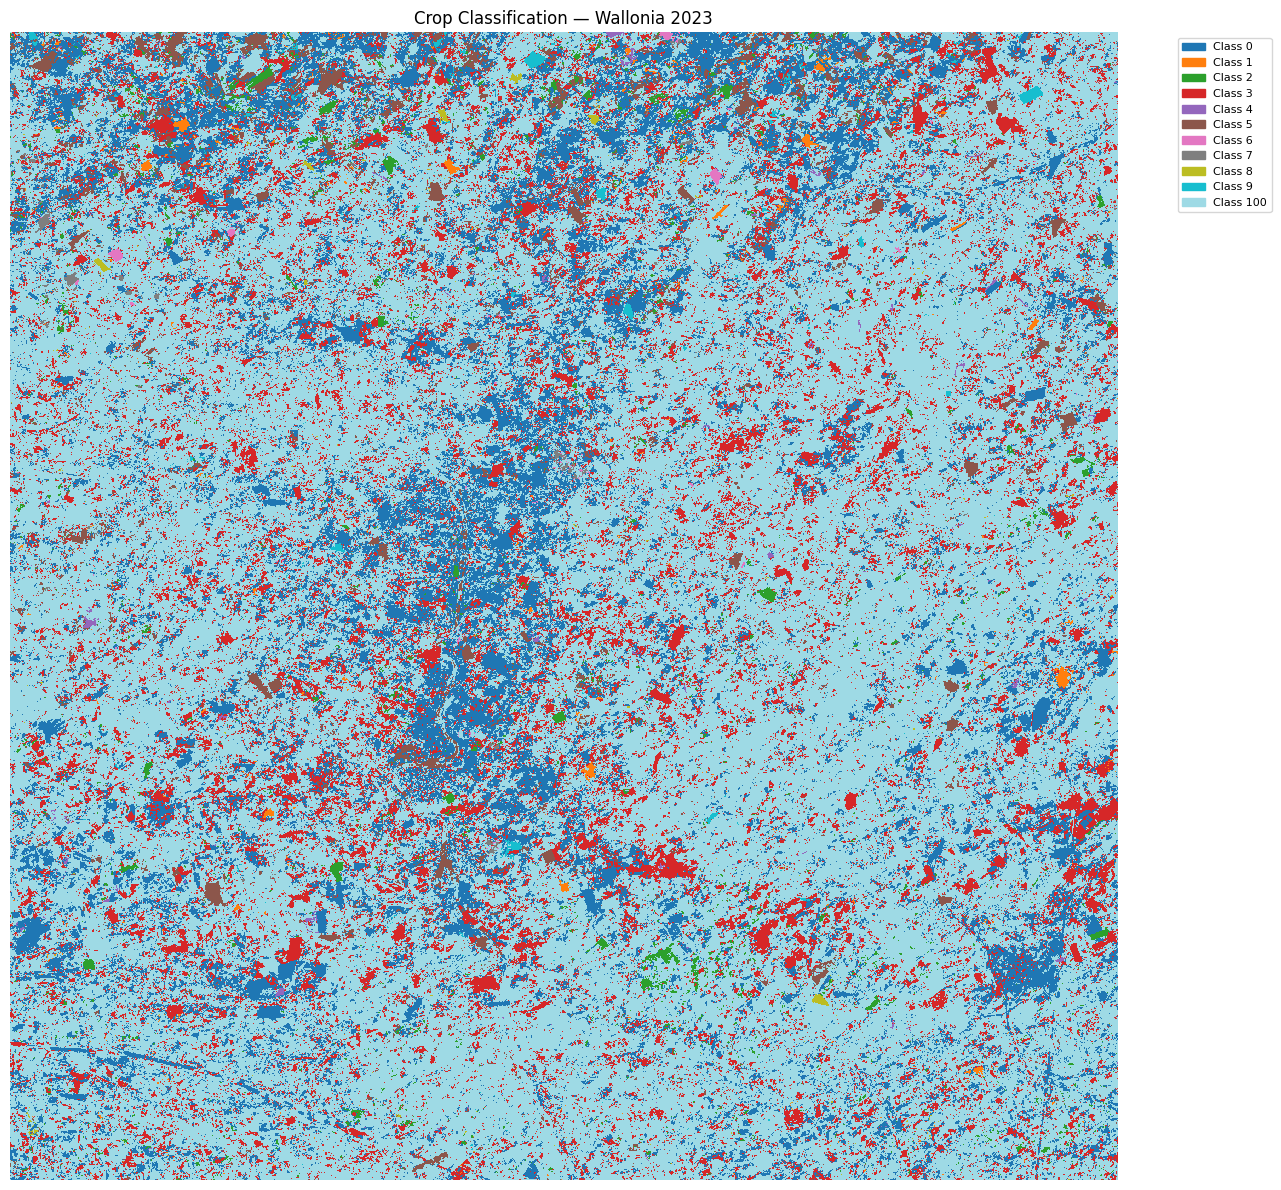

Saved final_crop_map.png


In [9]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap

# Load the filtered map from cloud
filtered_map, _ = read_blob('jan/results/reclassed_RF_fast_filtered_all.tif')
filtered_map = filtered_map.astype(int)

# Get unique class codes
classes = sorted(np.unique(filtered_map))
classes = [c for c in classes if c != int(NO_DATA)]
print(f'{len(classes)} classes: {classes}')

# Build colour map and legend
cmap = plt.cm.get_cmap('tab20', len(classes))
class_to_idx = {c: i for i, c in enumerate(classes)}

# Map array to sequential indices for plotting
plot_arr = np.full_like(filtered_map, dtype=float, fill_value=np.nan)
for c in classes:
    plot_arr[filtered_map == c] = class_to_idx[c]

# Legend patches
patches = [mpatches.Patch(color=cmap(i), label=f'Class {c}') for i, c in enumerate(classes)]

# Plot
fig, ax = plt.subplots(1, 1, figsize=(14, 12))
im = ax.imshow(plot_arr, cmap=cmap, interpolation='nearest')
ax.legend(handles=patches, bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
ax.set_title('Crop Classification — Wallonia 2023')
ax.axis('off')
plt.tight_layout()
plt.savefig('final_crop_map.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved final_crop_map.png')

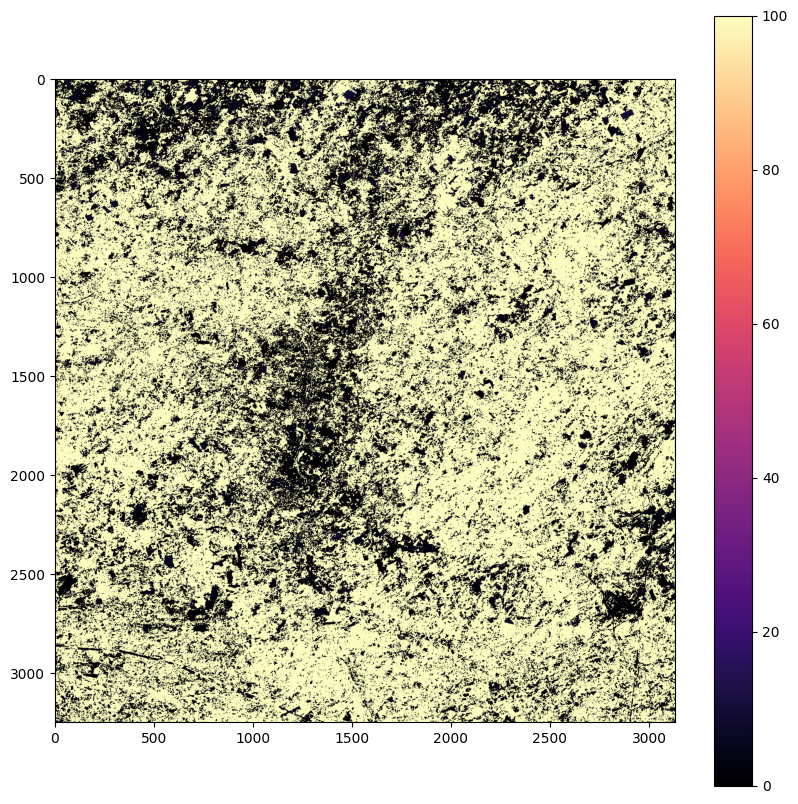

In [20]:
plt.figure(figsize=(10, 10))
plt.imshow(filtered_map, cmap="magma")
plt.colorbar()
#plt.savefig("classif_RF_basic.png")
plt.show()

In [11]:
# Build colour map and legend
#cmap = plt.cm.get_cmap('tab20', len(classes))
#cmap='magma'
class_to_idx = {c: i for i, c in enumerate(classes)}

# Map array to sequential indices for plotting
plot_arr = np.full_like(filtered_map, dtype=float, fill_value=np.nan)
for c in classes:
    plot_arr[filtered_map == c] = class_to_idx[c]

# Legend patches
patches = [mpatches.Patch(color=cmap(i), label=f'Class {c}') for i, c in enumerate(classes)]

# Plot
fig, ax = plt.subplots(1, 1, figsize=(14, 12))
im = ax.imshow(plot_arr, cmap="magma", interpolation='nearest')
ax.legend(handles=patches, bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
ax.set_title('Crop Classification — Wallonia 2023')
ax.axis('off')
plt.tight_layout()
plt.savefig('final_crop_map.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved final_crop_map.png')

TypeError: 'str' object is not callable

## Step 20 — Download Results

🎯 Download your final GeoTIFF results to the JupyterLab local filesystem so you can save them to your laptop.

Then right-click each file in the JupyterLab file browser and select **Download** to save to your local machine.

In [ ]:
def download_blob(blob_name, local_path):
    cc = get_cc()
    data = cc.download_blob(blob_name).readall()
    with open(local_path, 'wb') as f:
        f.write(data)
    print(f'Downloaded {blob_name} -> {local_path} ({len(data)/1e6:.1f} MB)')


download_blob('jan/results/reclassed_RF_fast_filtered_all.tif', 'final_map.tif')
download_blob('jan/results/classification_RF.tif',              'raw_classification.tif')
print('Results downloaded. Right-click files in the JupyterLab browser to save locally.')

## Step 21 — Clean Up Azure Resources

⚠️ **Do this only after downloading all results you want to keep.**

1. Go to **portal.azure.com**
2. **Resource groups** → your group resource group
3. Click **Delete resource group**
4. Type the resource group name to confirm → **Delete**

This removes all resources (compute instance, storage, ML workspace) and stops all costs permanently.

Your Azure for Students account and remaining $100 credit are **not affected**.

---

## 🎉 Congratulations!

You have built a complete end-to-end satellite image classification pipeline on Azure:

- ✅ Provisioned cloud infrastructure from scratch
- ✅ Downloaded Sentinel-2 multi-band data via the Copernicus S3 API
- ✅ Applied cloud masking and computed monthly composites
- ✅ Built a multi-temporal feature stack with spectral indices
- ✅ Selected informative features using Random Forest importance
- ✅ Trained and evaluated a crop type classifier
- ✅ Produced a final classified land cover map of Wallonia

---